# Train instance — chapter 3

One trainer for **instance-level classification and regression**. Wav2Vec2-based. `task_type` is a Config flag, not a fork.

**Input**
- A canonical JSONL with scalar labels (e.g. `data/processed_jsonl/rog_dialog_instance.jsonl`).

**Output**
- `runs/{dataset}_{label_key}_{task_type}_{timestamp}/`
  - `phase1_dev/` — TRAIN→DEV per-epoch logs (no model saved)
  - `phase2_test/` — TRAIN+DEV→TEST per-epoch logs + `best_model/`

**Two-phase training (kept from your legacy scripts)**
1. *Development phase.* Train on TRAIN, eval on DEV every epoch. Use this to read tea leaves about hyperparams.
2. *Final phase.* Re-train on TRAIN ∪ DEV, eval on TEST every epoch. Save the best epoch's model. The DEV-set best epoch tells you *roughly* what training length to use; in this v1 we just run the same `num_epochs` again — pick the best one on TEST.

**What's the same across tasks**
- Canonical JSONL loader (filters by `split`, extracts `labels[label_key]`).
- Audio preprocessing (load → mono → 16k → feature_extractor).
- `EpochCheckpointCallback` evaluates the eval set every epoch, writes per-epoch artifacts.

**What differs by task**
- *Classification*: stock `AutoModelForAudioClassification`. Metrics: macro-F1, accuracy, Spearman (ordinal-aware). Per-epoch plots: confusion matrix.
- *Regression*: custom `Wav2Vec2ForRegression` (masked mean-pool + Linear(1)). Metrics: MSE, MAE, Spearman. Per-epoch plots: scatter + distribution.

---

## 0. Setup

In [1]:
import os
import sys
from pathlib import Path

# Find PROJECT_ROOT via utils_dataprep (chapter 1 already does this).
HERE = Path.cwd()
if HERE.name != "3_instance_models":
    candidate = HERE / "3_instance_models"
    if candidate.exists():
        HERE = candidate
sys.path.insert(0, str(HERE.parent / "1_data_prep"))

import utils_dataprep as udp
PROJECT_ROOT = udp.PROJECT_ROOT

# Cache HF pretrained models in a project-local folder (gitignored) instead of
# ~/.cache/huggingface, so the download survives across machines / reclones.
# MUST be set BEFORE any `from transformers import ...` — HF reads HF_HOME at
# import time and caches the resolved path internally.
# Note: if PROJECT_ROOT ends up wrong (e.g. notebook launched from an odd cwd),
# HF_HOME will point somewhere unexpected; check the printout below.
os.environ["HF_HOME"] = str(PROJECT_ROOT / "stock_models")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Chapter dir  = {HERE}")
print(f"HF_HOME      = {os.environ['HF_HOME']}")


PROJECT_ROOT = /home/ivan/Posao_IJS/Stepping_Stones/github_full_repo/slavic-speech-pipeline
Chapter dir  = /home/ivan/Posao_IJS/Stepping_Stones/github_full_repo/slavic-speech-pipeline/3_instance_models
HF_HOME      = /home/ivan/Posao_IJS/Stepping_Stones/github_full_repo/slavic-speech-pipeline/stock_models


Standard third-party imports.

In [2]:
import json
import shutil
from collections import Counter
from dataclasses import dataclass, field
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import torch
import torch.nn as nn
from datasets import Dataset
from scipy.stats import spearmanr
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, mean_absolute_error, mean_squared_error,
)
from transformers import (
    AutoConfig, AutoFeatureExtractor, AutoModelForAudioClassification,
    Trainer, TrainerCallback, TrainingArguments,
    Wav2Vec2Model, Wav2Vec2PreTrainedModel,
)

plt.rcParams["figure.dpi"] = 100

---

## 0.5 Target presets — pick what you train on

What combinations of *(dataset, label)* this trainer can handle. Pick one via
`Config.target` below; the resolver fills in `jsonl_path`, `label_key`,
`task_type`, and (for classification) `label_order`.

Keys are short, stable strings. To add a new target, just add an entry here —
`Config.target` is the only downstream knob.

`label_order: None` means "build it from the data union at load time" (used for
targets with many or unstable label spaces, e.g. `dialogue_act_function`).


In [3]:
TARGETS: dict = {
    # ---- ROG-Art (rog_instance.jsonl) ----------------------------------
    "rog_art_filled_pause": {
        "jsonl_path": "data/processed_jsonl/rog_instance.jsonl",
        "label_key":  "filled_pause_present",
        "task_type":  "classification",
        "label_order": [0, 1],
    },
    "rog_art_disfluency_count": {
        "jsonl_path": "data/processed_jsonl/rog_instance.jsonl",
        "label_key":  "disfluency_count",
        "task_type":  "classification",
        "label_order": [0, 1, 2],   # class 2 is ~0.5% of rows; macro-F1 will be brutal
    },

    # ---- ROG-Dialog (rog_dialog_instance.jsonl) ------------------------
    "rog_dia_sentiment": {
        "jsonl_path": "data/processed_jsonl/rog_dialog_instance.jsonl",
        "label_key":  "sentiment",
        "task_type":  "classification",
        "label_order": [
            "predominantlyNegative", "mixedNegative", "neutralNegative",
            "neutralPositive", "mixedPositive", "predominantlyPositive",
        ],
    },
    "rog_dia_sentiment_annotated": {
        "jsonl_path": "data/processed_jsonl/rog_dialog_instance.jsonl",
        "label_key":  "sentiment_annotated",
        "task_type":  "classification",
        "label_order": [
            "predominantlyNegative", "mixedNegative", "neutralNegative",
            "neutralPositive", "mixedPositive", "predominantlyPositive",
        ],
    },
    "rog_dia_dialogue_act_dimension": {
        "jsonl_path": "data/processed_jsonl/rog_dialog_instance.jsonl",
        "label_key":  "dialogue_act_dimension",
        "task_type":  "classification",
        # ~8 categories; non-ordinal, so Spearman is uninterpretable here.
        "label_order": [
            "task", "discourseStructuring", "autoFeedback", "timeManagement",
            "alloFeedback", "turnManagement", "ownCommunicationManagement",
            "unspecifiedDimension",
        ],
    },
    "rog_dia_dialogue_act_function": {
        "jsonl_path": "data/processed_jsonl/rog_dialog_instance.jsonl",
        "label_key":  "dialogue_act_function",
        "task_type":  "classification",
        # 30+ categories with a long tail; let the loader build label_order
        # from the data. The confusion matrix at the end will be unreadable.
        "label_order": None,
    },

    # ---- ParlaSpeech (TODO) --------------------------------------------
    # Needs 11c_prep_ParlaSpeech.ipynb to produce the JSONL first. Uncomment
    # once data/processed_jsonl/parlaspeech_instance.jsonl exists.
    # "parlaspeech_filled_pause": {
    #     "jsonl_path": "data/processed_jsonl/parlaspeech_instance.jsonl",
    #     "label_key":  "filled_pause_present",
    #     "task_type":  "classification",
    #     "label_order": [0, 1],
    # },
}


def resolve_target(cfg, targets: dict) -> None:
    """Overwrite jsonl_path/label_key/task_type/label_order from the picked
    preset. Mutates cfg in place. Raises if cfg.target isn't a known key."""
    if cfg.target not in targets:
        raise ValueError(
            f"Config.target={cfg.target!r} not in TARGETS. "
            f"Known: {sorted(targets)}"
        )
    t = targets[cfg.target]
    cfg.jsonl_path  = t["jsonl_path"]
    cfg.label_key   = t["label_key"]
    cfg.task_type   = t["task_type"]
    cfg.label_order = t["label_order"]   # may be None — built from data later


print(f"available targets: {sorted(TARGETS)}")


available targets: ['rog_art_disfluency_count', 'rog_art_filled_pause', 'rog_dia_dialogue_act_dimension', 'rog_dia_dialogue_act_function', 'rog_dia_sentiment', 'rog_dia_sentiment_annotated']


---

## 1. Config

All knobs are here.

**Important rules**
- `task_type`: `"classification"` or `"regression"`.
- `label_key`: which key inside `labels` to train on (e.g. `"primary_stress_present"`, `"sentiment"`).
- `label_order`: **required for classification.** This is the canonical ordering of the label space (used as `id2label` *and* for ordinal Spearman). If unset, training fails with a loud error.
- `label_scale`: regression-only. Maps class string → float; if None, labels must already be numeric in the JSONL.
- `model_name`: defaults to a tiny random model when `test_mode=True`, otherwise to the real Wav2Vec2-XLS-R 300M.
- `use_cuda`: **False by default.** Flip to True on a GPU box.
- `test_mode`: small model, 1 epoch, batch 2, outputs under `runs/test/` + `models/test/`.

**Output layout**
- `runs/<run_name>/` — per-epoch logs, predictions, plots, config snapshot. **One folder per run.** Lightweight (~MB).
- `models/<run_name>/best_model/` — the final saved model weights + best epoch's artifacts. **Heavy** (~1 GB for XLS-R 300M).

Both `runs/` and `models/` are gitignored. Keeping them separate means you can delete `models/` to reclaim disk without losing the experimental record.

**⚠️ CPU training of the real (300M) model needs ~4–5 GB of working RAM** *on top of* the OS and your IDE. If VS Code is crashing on you, you have three options:
1. Use a smaller model (`facebook/wav2vec2-base` is ~95M, 4× smaller).
2. Drop `batch_size` to 2 and `grad_accum` to 1 to shrink activations.
3. Train on a GPU box (CUDA halves peak memory and is 50× faster).

In [ ]:
@dataclass
class Config:
    # -- Target preset -------------------------------------------------------
    # Pick from the TARGETS dict above. The resolver fills jsonl_path /
    # label_key / task_type / label_order from the picked preset, so those
    # fields below are placeholders that will be overwritten.
    target: str = "rog_dia_sentiment"

    # -- Data (overwritten by resolve_target) -------------------------------
    jsonl_path:  str  = ""
    label_key:   str  = ""
    task_type:   str  = "classification"  # "classification" | "regression"
    label_order: list | None = None

    # Regression: optional class→float map. If None, labels must already be numeric.
    label_scale: dict | None = None

    # -- Model ---------------------------------------------------------------
    model_name: str              = "facebook/wav2vec2-base"
    freeze_feature_encoder: bool = True
    loss_function: str           = "mse"   # regression only: "mse" | "l1"

    # -- Training ------------------------------------------------------------
    batch_size: int      = 4
    grad_accum: int      = 1
    learning_rate: float = 1e-5
    num_epochs: int      = 10
    max_grad_norm: float = 1.0
    warmup_ratio: float  = 0.10

    # -- Output --------------------------------------------------------------
    runs_dir: str   = "runs"     # per-epoch logs + per-phase summaries
    models_dir: str = "models"   # best_model/ goes here, gitignored

    # -- Best-epoch selection ------------------------------------------------
    best_metric_classification: str = "macro_f1"    # | "accuracy" | "spearman"
    best_metric_regression:     str = "spearman"    # | "mse" | "mae"

    # -- Preprocessing -------------------------------------------------------
    preprocess_batch_size: int  = 1
    dataloader_num_workers: int = 0   # 0 keeps RAM predictable on CPU

    # -- Hardware ------------------------------------------------------------
    use_cuda: bool   = False    # default CPU; flip True on GPU
    cuda_device: str = "0"

    # -- Test mode -----------------------------------------------------------
    test_mode: bool       = True
    test_n_train: int     = 200
    test_n_dev: int       = 24
    test_n_test: int      = 24
    test_model_name: str  = "hf-internal-testing/tiny-random-wav2vec2"
    test_num_epochs: int  = 1
    test_batch_size: int  = 2


cfg = Config()
resolve_target(cfg, TARGETS)

# Apply test-mode clamps
if cfg.test_mode:
    udp.banner("🧪 TEST MODE", char="-")
    cfg.model_name = cfg.test_model_name
    cfg.num_epochs = cfg.test_num_epochs
    cfg.batch_size = cfg.test_batch_size
    cfg.grad_accum = 1
    cfg.runs_dir   = "runs/test"
    cfg.models_dir = "models/test"

# Device resolution
if cfg.use_cuda and torch.cuda.is_available():
    os.environ["CUDA_VISIBLE_DEVICES"] = cfg.cuda_device
    DEVICE = "cuda"
elif cfg.use_cuda and not torch.cuda.is_available():
    print("⚠️  use_cuda=True but no CUDA device available; falling back to CPU")
    DEVICE = "cpu"
else:
    DEVICE = "cpu"

print(f"target      = {cfg.target}")
print(f"jsonl_path  = {cfg.jsonl_path}")
print(f"label_key   = {cfg.label_key}")
print(f"task_type   = {cfg.task_type}")
print(f"label_order = {cfg.label_order}")
print(f"device      = {DEVICE}")



----------------------------------------------------------------------
🧪 TEST MODE
----------------------------------------------------------------------
target      = rog_dia_sentiment
jsonl_path  = data/processed_jsonl/rog_dialog_instance.jsonl
label_key   = sentiment
task_type   = classification
label_order = ['predominantlyNegative', 'mixedNegative', 'neutralNegative', 'neutralPositive', 'mixedPositive', 'predominantlyPositive']
device      = cpu


---

## 2. Validate the config before doing real work

Fail loud here so you don't burn 4 hours of training only to learn `label_order` was missing.

In [5]:
def validate_config(cfg: Config) -> None:
    if cfg.task_type not in ("classification", "regression"):
        raise ValueError(f"task_type must be 'classification' or 'regression', got {cfg.task_type!r}")
    if cfg.task_type == "classification":
        # label_order=None is allowed here — it signals "build from data union
        # after JSONL load". The label-mapping cell handles that path.
        if cfg.label_order is not None:
            if len(set(cfg.label_order)) != len(cfg.label_order):
                raise ValueError(f"label_order has duplicates: {cfg.label_order}")
    if cfg.task_type == "regression" and cfg.loss_function not in ("mse", "l1"):
        raise ValueError(f"loss_function must be 'mse' or 'l1', got {cfg.loss_function!r}")
    if cfg.best_metric_classification not in ("macro_f1", "accuracy", "spearman"):
        raise ValueError(f"best_metric_classification: invalid {cfg.best_metric_classification!r}")
    if cfg.best_metric_regression not in ("spearman", "mse", "mae"):
        raise ValueError(f"best_metric_regression: invalid {cfg.best_metric_regression!r}")

validate_config(cfg)
print("✅ config valid")


✅ config valid


---

## 3. Load JSONL, filter to records that carry `label_key`

Records missing the target label are silently dropped — chapter-2 sniff would have already alerted you if this is a big fraction.

In [6]:
def load_split(jsonl_path: str, split: str, label_key: str) -> list[dict]:
    out = []
    for r in udp.iter_jsonl(jsonl_path):
        if r["split"] != split:
            continue
        if label_key not in r.get("labels", {}):
            continue
        if r["labels"][label_key] is None:
            continue
        out.append(r)
    return out


train_records = load_split(cfg.jsonl_path, "train", cfg.label_key)
dev_records   = load_split(cfg.jsonl_path, "dev",   cfg.label_key)
test_records  = load_split(cfg.jsonl_path, "test",  cfg.label_key)

if cfg.test_mode:
    train_records = train_records[: cfg.test_n_train]
    dev_records   = dev_records[:   cfg.test_n_dev]
    test_records  = test_records[:  cfg.test_n_test]

print(f"train: {len(train_records)}")
print(f"dev:   {len(dev_records)}")
print(f"test:  {len(test_records)}")
if not train_records or not dev_records or not test_records:
    raise ValueError("one of the splits is empty after filtering for label_key — check the JSONL")

train: 200
dev:   24
test:  24


---

## 4. Build label mappings (classification) or scale labels (regression)

For classification: `label_order` is the source of truth — `label2id[label] = index in label_order`. Any class encountered in the data that *isn't* in `label_order` is a hard error.

For regression: if `label_scale` is set, map class → float; otherwise the label must already be numeric.

In [7]:
if cfg.task_type == "classification":
    # If the target preset left label_order=None, build it from the data union.
    # Sorted for stable ordering across runs.
    if cfg.label_order is None:
        seen_vals = sorted({
            r["labels"][cfg.label_key]
            for r in (train_records + dev_records + test_records)
        }, key=str)
        cfg.label_order = seen_vals
        print(f"📌 auto-built label_order from data ({len(seen_vals)} classes): {seen_vals}")

    label2id = {lab: i for i, lab in enumerate(cfg.label_order)}
    id2label = {i: lab for i, lab in enumerate(cfg.label_order)}
    num_labels = len(cfg.label_order)

    # Validate all seen labels are in label_order
    seen = {r["labels"][cfg.label_key] for r in (train_records + dev_records + test_records)}
    unknown = seen - set(label2id)
    if unknown:
        raise ValueError(
            f"Found labels not in Config.label_order: {sorted(map(str, unknown))}. "
            f"Either add them to label_order or fix the data."
        )

    # Print per-split distribution
    print(f"Labels ({num_labels}, canonical order):")
    for lab in cfg.label_order:
        n_tr = sum(1 for r in train_records if r["labels"][cfg.label_key] == lab)
        n_dv = sum(1 for r in dev_records   if r["labels"][cfg.label_key] == lab)
        n_te = sum(1 for r in test_records  if r["labels"][cfg.label_key] == lab)
        print(f"   {str(lab):<28} train={n_tr:>4}  dev={n_dv:>4}  test={n_te:>4}")
else:
    label2id, id2label, num_labels = None, None, 1
    # Regression: validate labels are numeric (or scaleable)
    for r in train_records + dev_records + test_records:
        v = r["labels"][cfg.label_key]
        if isinstance(v, (int, float)):
            continue
        if cfg.label_scale is not None and v in cfg.label_scale:
            continue
        raise ValueError(
            f"{r['instance_id']}: regression label is {v!r} (type {type(v).__name__}), "
            f"not numeric and no label_scale mapping. Either provide label_scale or fix the data."
        )
    print(f"Regression target: '{cfg.label_key}'")


Labels (6, canonical order):
   predominantlyNegative        train=   2  dev=   0  test=   4
   mixedNegative                train=  11  dev=   0  test=   3
   neutralNegative              train=  16  dev=   0  test=   4
   neutralPositive              train= 142  dev=  24  test=  11
   mixedPositive                train=   8  dev=   0  test=   0
   predominantlyPositive        train=  21  dev=   0  test=   2


---

## 5. Audio loading and feature extraction

`prepare_dataset_dict` reads a list of canonical records and produces the list-of-dicts that HuggingFace `Dataset.from_list` wants: `audio_path`, `label`, plus any provenance fields we want to thread through to predictions.json.

`preprocess_function` (run via `.map(batched=True)`) loads each WAV, ensures mono + 16 kHz, and passes through the feature extractor without padding (collator handles padding).

In [8]:
def label_to_value(r: dict, cfg: Config, label2id: dict | None) -> int | float:
    v = r["labels"][cfg.label_key]
    if cfg.task_type == "classification":
        return label2id[v]
    if cfg.label_scale is not None and v in cfg.label_scale:
        return float(cfg.label_scale[v])
    return float(v)


def prepare_dataset_dict(records: list[dict], cfg: Config, label2id: dict | None) -> list[dict]:
    items = []
    for r in records:
        items.append({
            "instance_id": r["instance_id"],
            "file_id":     r.get("file_id", ""),
            "start_t":     r.get("start_t"),
            "end_t":       r.get("end_t"),
            "audio_path":  str(udp.from_project_relative(r["audio_path"])),
            "label":       label_to_value(r, cfg, label2id),
            "label_class": r["labels"][cfg.label_key],   # original string/int for reporting
        })
    return items


def preprocess_function(examples, feature_extractor):
    """Load each WAV via soundfile. Chapter-1 splitter guarantees 16 kHz mono PCM-16;
    we sanity-check and resample as a defensive fallback."""
    audio_arrays = []
    for path in examples["audio_path"]:
        data, sr = sf.read(path, dtype="float32", always_2d=False)
        if data.ndim == 2:
            data = data.mean(axis=1)
        if sr != 16000:
            # Shouldn't happen if chapter 1 ran cleanly, but resample as a fallback.
            import librosa
            data = librosa.resample(data, orig_sr=sr, target_sr=16000)
        audio_arrays.append(data)
    inputs = feature_extractor(
        audio_arrays, sampling_rate=16000, return_tensors=None, padding=False,
    )
    return {"input_values": inputs["input_values"], "labels": examples["label"]}

---

## 6. Data collator (pad audio within each batch)

The feature extractor doesn't pad; this does. Labels are floats for regression, longs for classification.

In [9]:
class DataCollatorForInstance:
    def __init__(self, feature_extractor, task_type: str):
        self.feature_extractor = feature_extractor
        self.task_type = task_type

    def __call__(self, features):
        input_values = [f["input_values"] for f in features]
        labels = [f["labels"] for f in features]
        batch = self.feature_extractor.pad(
            {"input_values": input_values}, padding=True, return_tensors="pt"
        )
        if self.task_type == "classification":
            batch["labels"] = torch.tensor(labels, dtype=torch.long)
        else:
            batch["labels"] = torch.tensor(labels, dtype=torch.float32)
        return batch

---

## 7. Model factory

Two branches:
- *Classification* → `AutoModelForAudioClassification.from_pretrained(...)`. Stock head, nothing custom.
- *Regression* → `Wav2Vec2ForRegression` with masked mean-pooling. Built from scratch and the pretrained `wav2vec2` submodule is loaded into it.

`freeze_feature_encoder` flag freezes the CNN front-end in either case.

In [10]:
class Wav2Vec2ForRegression(Wav2Vec2PreTrainedModel):
    """Wav2Vec2 + masked mean-pooling + Linear(1). MSE or L1 loss."""

    def __init__(self, config, loss_type: str = "mse"):
        super().__init__(config)
        self.wav2vec2 = Wav2Vec2Model(config)
        self.regression_head = nn.Linear(config.hidden_size, 1)
        self.loss_type = loss_type
        self.post_init()

    def _get_feature_vector_attention_mask(self, feature_vector_length, attention_mask):
        stride = attention_mask.shape[1] / feature_vector_length
        indices = (torch.arange(feature_vector_length, device=attention_mask.device) * stride).long()
        indices = torch.clamp(indices, max=attention_mask.shape[1] - 1)
        return torch.index_select(attention_mask, 1, indices)

    def forward(self, input_values, attention_mask=None, labels=None):
        outputs = self.wav2vec2(input_values, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state
        if attention_mask is not None:
            sub_mask = self._get_feature_vector_attention_mask(last_hidden.shape[1], attention_mask)
            mask = sub_mask.unsqueeze(-1).float()
            sum_h = (last_hidden * mask).sum(dim=1)
            cnt = torch.clamp(mask.sum(dim=1), min=1e-9)
            hidden = sum_h / cnt
        else:
            hidden = last_hidden.mean(dim=1)
        logits = self.regression_head(hidden)
        loss = None
        if labels is not None:
            fct = nn.MSELoss() if self.loss_type == "mse" else nn.L1Loss()
            loss = fct(logits.view(-1), labels.view(-1))
        return {"loss": loss, "logits": logits.view(-1)}


def build_model(cfg: Config, num_labels: int, label2id, id2label):
    if cfg.task_type == "classification":
        # HF transformers 5.x requires label2id keys to be str. Stringify here
        # for the from_pretrained call; internal label2id can still use native types.
        hf_label2id = {str(k): int(v) for k, v in label2id.items()}
        hf_id2label = {int(k): str(v) for k, v in id2label.items()}
        model = AutoModelForAudioClassification.from_pretrained(
            cfg.model_name,
            num_labels=num_labels,
            label2id=hf_label2id, id2label=hf_id2label,
            ignore_mismatched_sizes=True,
        )
    else:
        config_obj = AutoConfig.from_pretrained(cfg.model_name, num_labels=num_labels)
        model = Wav2Vec2ForRegression(config_obj, loss_type=cfg.loss_function)
        model.wav2vec2 = Wav2Vec2Model.from_pretrained(
            cfg.model_name, config=config_obj, ignore_mismatched_sizes=True,
        )

    if cfg.freeze_feature_encoder:
        model.wav2vec2.freeze_feature_encoder()
        print("🔒 feature encoder (CNN) frozen")
    return model

---

## 8. Metrics dispatcher

- *Classification*: macro-F1, accuracy, Spearman (computed on class indices in `label_order`; only interpretable for ordinal label spaces but always reported).
- *Regression*: MSE, MAE, Spearman + p-value.

In [11]:
def compute_classification_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    acc = accuracy_score(labels, preds)
    if len(set(labels)) > 1 and len(set(preds)) > 1:
        rho, _ = spearmanr(labels, preds)
        rho = float(rho) if not np.isnan(rho) else float("nan")
    else:
        rho = float("nan")
    return {"macro_f1": macro_f1, "accuracy": acc, "spearman": rho}


def compute_regression_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.reshape(-1)
    labels = labels.reshape(-1)
    mse = float(mean_squared_error(labels, preds))
    mae = float(mean_absolute_error(labels, preds))
    if len(set(labels.tolist())) > 1 and len(set(preds.tolist())) > 1:
        rho, p = spearmanr(labels, preds)
        rho = float(rho) if not np.isnan(rho) else float("nan")
        p = float(p) if not np.isnan(p) else float("nan")
    else:
        rho, p = float("nan"), float("nan")
    return {"mse": mse, "mae": mae, "spearman": rho, "spearman_p_value": p}


def get_compute_metrics(cfg: Config):
    return (compute_classification_metrics if cfg.task_type == "classification"
            else compute_regression_metrics)

---

## 9. Per-epoch artifacts

- *Classification* → confusion matrix (absolute + relative) + `classification_report.txt`.
- *Regression* → scatter (gold vs pred) + distribution histograms.

In [12]:
def save_predictions_json(predictions, labels, items, out_path: Path, task_type: str,
                          id2label: dict | None):
    out = []
    for i, item in enumerate(items):
        gold = labels[i]
        pred = predictions[i] if task_type == "regression" else int(np.argmax(predictions[i]))
        out.append({
            "instance_id": item["instance_id"],
            "file_id":     item.get("file_id", ""),
            "start_t":     item.get("start_t"),
            "end_t":       item.get("end_t"),
            "gold_label":  (id2label[int(gold)] if (task_type == "classification" and id2label) else float(gold)),
            "pred_label":  (id2label[pred]      if (task_type == "classification" and id2label) else float(pred)),
            "gold_raw":    float(gold),
            "pred_raw":    float(pred) if task_type == "regression" else None,
        })
    out_path.write_text(json.dumps(out, indent=2, ensure_ascii=False))


def plot_confusion_matrix(y_true_idx, y_pred_idx, label_order: list, out_dir: Path):
    # Stringify labels for plot/report (label_order may be ints like [0,1])
    str_labels = [str(x) for x in label_order]
    cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(len(label_order))))
    # Absolute
    fig, ax = plt.subplots(figsize=(max(6, len(label_order)*1.2), max(5, len(label_order))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
                xticklabels=str_labels, yticklabels=str_labels, ax=ax)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("confusion matrix (counts)")
    plt.tight_layout(); fig.savefig(out_dir / "confusion_matrix.png"); plt.close(fig)
    # Relative
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_rel = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float),
                       where=row_sums != 0) * 100.0
    fig, ax = plt.subplots(figsize=(max(6, len(label_order)*1.2), max(5, len(label_order))))
    sns.heatmap(cm_rel, annot=True, fmt=".1f", cmap="viridis",
                xticklabels=str_labels, yticklabels=str_labels, ax=ax)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("confusion matrix (%)")
    plt.tight_layout(); fig.savefig(out_dir / "confusion_matrix_relative.png"); plt.close(fig)
    # Report
    report = classification_report(y_true_idx, y_pred_idx,
                                   labels=list(range(len(label_order))),
                                   target_names=str_labels, digits=4, zero_division=0)
    (out_dir / "classification_report.txt").write_text(report)


def plot_scatter(gold, pred, out_path: Path):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(gold, pred, alpha=0.4)
    lo = float(min(gold.min(), pred.min())); hi = float(max(gold.max(), pred.max()))
    ax.plot([lo, hi], [lo, hi], "--", linewidth=1)
    ax.set_xlabel("gold"); ax.set_ylabel("pred"); ax.set_title("gold vs pred")
    plt.tight_layout(); fig.savefig(out_path); plt.close(fig)


def plot_distribution(gold, pred, out_path: Path):
    fig, ax = plt.subplots(figsize=(8, 4))
    bins = 30
    ax.hist(gold, bins=bins, alpha=0.5, label="gold")
    ax.hist(pred, bins=bins, alpha=0.5, label="pred")
    ax.legend(); ax.set_title("label distribution: gold vs pred")
    plt.tight_layout(); fig.savefig(out_path); plt.close(fig)

---

## 10. `EpochCheckpointCallback`

Evaluates the eval set every epoch, writes per-epoch logs. Does **not** save model weights — only the best epoch's model is saved, and only in phase 2.

In [13]:
class EpochCheckpointCallback(TrainerCallback):
    def __init__(self, phase_dir: Path, eval_dataset, eval_items,
                 compute_metrics, data_collator, cfg: Config,
                 label_order=None, id2label=None):
        self.phase_dir = phase_dir
        self.logs_dir = phase_dir / "epoch_logs"
        self.logs_dir.mkdir(parents=True, exist_ok=True)
        self.eval_dataset = eval_dataset
        self.eval_items = eval_items
        self.compute_metrics = compute_metrics
        self.data_collator = data_collator
        self.cfg = cfg
        self.label_order = label_order
        self.id2label = id2label
        self.epoch_results: list[dict] = []

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        epoch = int(state.epoch)
        print(f"\n💾 logging epoch {epoch}…")
        epoch_dir = self.logs_dir / f"epoch_{epoch}"
        epoch_dir.mkdir(parents=True, exist_ok=True)

        eval_trainer = Trainer(
            model=model, args=args,
            compute_metrics=self.compute_metrics,
            data_collator=self.data_collator,
        )
        out = eval_trainer.predict(self.eval_dataset)

        # Normalize "test_..." → "eval_..." (HF predict uses 'test_' prefix)
        metrics = {k.replace("test_", "eval_"): v for k, v in out.metrics.items()}

        # Latest train loss
        train_loss = None
        for log in reversed(state.log_history):
            if "loss" in log:
                train_loss = log["loss"]; break

        epoch_info = {"epoch": epoch, "train_loss": train_loss, **metrics}
        self.epoch_results.append(epoch_info)

        # predictions.json
        save_predictions_json(
            out.predictions, out.label_ids, self.eval_items,
            epoch_dir / "predictions.json",
            task_type=self.cfg.task_type, id2label=self.id2label,
        )

        # Plots
        if self.cfg.task_type == "classification":
            pred_idx = np.argmax(out.predictions, axis=-1)
            plot_confusion_matrix(out.label_ids, pred_idx, self.label_order, epoch_dir)
        else:
            gold = np.asarray(out.label_ids).reshape(-1)
            pred = np.asarray(out.predictions).reshape(-1)
            plot_scatter(gold, pred, epoch_dir / "scatter_plot.png")
            plot_distribution(gold, pred, epoch_dir / "distribution_plot.png")

        (epoch_dir / "epoch_summary.json").write_text(json.dumps(epoch_info, indent=2))

        # Pretty one-line summary
        if self.cfg.task_type == "classification":
            print(f"   epoch={epoch}  f1={metrics.get('eval_macro_f1', 0):.4f}  "
                  f"acc={metrics.get('eval_accuracy', 0):.4f}  "
                  f"rho={metrics.get('eval_spearman', float('nan')):.4f}")
        else:
            print(f"   epoch={epoch}  mse={metrics.get('eval_mse', 0):.4f}  "
                  f"mae={metrics.get('eval_mae', 0):.4f}  "
                  f"rho={metrics.get('eval_spearman', float('nan')):.4f}")

---

## 11. `run_phase` — train + evaluate + save logs

One function used by both phases. The only differences between phase 1 and phase 2 are:
- Which records make up the train set.
- Which split is the eval set.
- Whether the best model is saved.

In [14]:
def best_epoch_of(epoch_results: list[dict], cfg: Config) -> dict:
    if cfg.task_type == "classification":
        m = cfg.best_metric_classification
        return max(epoch_results, key=lambda r: (r.get(f"eval_{m}", float("-inf"))
                                                  if r.get(f"eval_{m}") is not None else float("-inf")))
    m = cfg.best_metric_regression
    if m in ("mse", "mae"):
        return min(epoch_results, key=lambda r: r.get(f"eval_{m}", float("inf")))
    return max(epoch_results, key=lambda r: (r.get(f"eval_{m}", float("-inf"))
                                              if r.get(f"eval_{m}") is not None else float("-inf")))


def run_phase(*, phase_name: str, train_records: list[dict], eval_records: list[dict],
              eval_split_name: str, save_best_model: bool,
              cfg: Config, run_dir: Path, model_dir: Path, feature_extractor,
              label2id, id2label) -> tuple[list[dict], dict]:
    udp.banner(f"PHASE: {phase_name}  (train→{eval_split_name})")
    phase_dir = run_dir / phase_name
    phase_dir.mkdir(parents=True, exist_ok=True)

    # Build items + datasets
    train_items = prepare_dataset_dict(train_records, cfg, label2id)
    eval_items  = prepare_dataset_dict(eval_records,  cfg, label2id)
    train_ds = Dataset.from_list(train_items)
    eval_ds  = Dataset.from_list(eval_items)

    # Preprocess (low batch_size keeps RAM predictable; HF datasets caches to arrow on disk)
    print(f"preprocessing {len(train_ds)} train + {len(eval_ds)} eval (batch_size={cfg.preprocess_batch_size})…")
    train_ds = train_ds.map(
        lambda x: preprocess_function(x, feature_extractor),
        batched=True, batch_size=cfg.preprocess_batch_size,
        remove_columns=train_ds.column_names,
    )
    eval_ds = eval_ds.map(
        lambda x: preprocess_function(x, feature_extractor),
        batched=True, batch_size=cfg.preprocess_batch_size,
        remove_columns=eval_ds.column_names,
    )
    label_dtype = "torch.long" if cfg.task_type == "classification" else "torch.float32"
    train_ds.set_format(type="torch", columns=["input_values", "labels"])
    eval_ds.set_format(type="torch", columns=["input_values", "labels"])

    # Model
    print(f"building model: {cfg.model_name}")
    model = build_model(cfg, num_labels=len(cfg.label_order) if cfg.task_type == "classification" else 1,
                        label2id=label2id, id2label=id2label)

    # Collator
    data_collator = DataCollatorForInstance(feature_extractor, cfg.task_type)
    compute_metrics = get_compute_metrics(cfg)

    # Warmup
    steps_per_epoch = max(1, len(train_ds) // (cfg.batch_size * cfg.grad_accum))
    total_steps = steps_per_epoch * cfg.num_epochs
    warmup_steps = int(total_steps * cfg.warmup_ratio)

    training_args = TrainingArguments(
        output_dir=str(phase_dir / "trainer_tmp"),
        eval_strategy="no",     # we eval in the callback
        save_strategy="no",
        logging_strategy="steps",
        logging_steps=10,
        report_to="none",
        label_names=["labels"],
        per_device_train_batch_size=cfg.batch_size,
        per_device_eval_batch_size=cfg.batch_size,
        num_train_epochs=cfg.num_epochs,
        gradient_accumulation_steps=cfg.grad_accum,
        learning_rate=cfg.learning_rate,
        warmup_steps=warmup_steps,
        lr_scheduler_type="linear",
        max_grad_norm=cfg.max_grad_norm,
        remove_unused_columns=False,
        use_cpu=(DEVICE == "cpu"),
        dataloader_num_workers=cfg.dataloader_num_workers,
    )

    callback = EpochCheckpointCallback(
        phase_dir=phase_dir, eval_dataset=eval_ds, eval_items=eval_items,
        compute_metrics=compute_metrics, data_collator=data_collator, cfg=cfg,
        label_order=cfg.label_order if cfg.task_type == "classification" else None,
        id2label=id2label,
    )

    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=train_ds, eval_dataset=eval_ds,
        compute_metrics=compute_metrics,
        data_collator=data_collator, callbacks=[callback],
    )
    print(f"🚀 training {cfg.num_epochs} epochs (bs={cfg.batch_size} ga={cfg.grad_accum} lr={cfg.learning_rate})")
    trainer.train()

    # Save phase-level summary
    (phase_dir / "all_epochs_summary.json").write_text(
        json.dumps(callback.epoch_results, indent=2)
    )
    best = best_epoch_of(callback.epoch_results, cfg)
    print(f"\n🏆 best epoch in {phase_name}: {best['epoch']}")
    for k, v in best.items():
        if isinstance(v, float):
            print(f"   {k}: {v:.4f}")
        else:
            print(f"   {k}: {v}")

    # Save best model (phase 2 only) → models/<run_name>/best_model/
    if save_best_model:
        best_dir = model_dir / "best_model"
        best_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(best_dir)
        feature_extractor.save_pretrained(best_dir)
        # Copy best epoch's artifacts (predictions.json, plots, summary)
        src = phase_dir / "epoch_logs" / f"epoch_{best['epoch']}"
        if src.exists():
            for f in src.iterdir():
                shutil.copy(f, best_dir / f.name)
        # Write a marker so you can see which run a model came from at a glance
        info_lines = [
            f"run_name: {run_dir.name}",
            f"run_dir:  {run_dir}",
            f"phase:    {phase_name}",
            f"epoch:    {best['epoch']}",
        ]
        (best_dir / "run_info.txt").write_text("\n".join(info_lines) + "\n")
        print(f"   saved best model → {best_dir.relative_to(PROJECT_ROOT)}")

    # Clean up Trainer's tmp dir
    shutil.rmtree(phase_dir / "trainer_tmp", ignore_errors=True)

    return callback.epoch_results, best

---

## 12. Set up the run directory

`runs/{dataset}_{label_key}_{task_type}_{timestamp}/`. The dataset is read from the first record (every record carries it).

In [15]:
dataset_name = train_records[0]["dataset"]
ts = datetime.now().strftime("%Y%m%d-%H%M%S")
run_name = f"{dataset_name}_{cfg.label_key}_{cfg.task_type}_{ts}"

run_dir   = udp.from_project_relative(cfg.runs_dir)   / run_name
model_dir = udp.from_project_relative(cfg.models_dir) / run_name
run_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)
print(f"run_dir   = {run_dir.relative_to(PROJECT_ROOT)}    (per-epoch logs)")
print(f"model_dir = {model_dir.relative_to(PROJECT_ROOT)}  (best_model goes here)")

# Save the resolved Config alongside the run for reproducibility
from dataclasses import asdict as _asdict
(run_dir / "config.json").write_text(json.dumps(_asdict(cfg), indent=2, default=str))

run_dir   = runs/test/ROG-Dialog_sentiment_classification_20260602-163655    (per-epoch logs)
model_dir = models/test/ROG-Dialog_sentiment_classification_20260602-163655  (best_model goes here)


1012

---

## 13. Load the feature extractor

Single load, reused across both phases.

In [16]:
print(f"loading feature extractor: {cfg.model_name}")
feature_extractor = AutoFeatureExtractor.from_pretrained(cfg.model_name)
print(f"   sampling_rate = {feature_extractor.sampling_rate}")

loading feature extractor: facebook/wav2vec2-base


   sampling_rate = 16000


---

## 14. Phase 1 — TRAIN → DEV (development)

Train on TRAIN, evaluate on DEV every epoch. No model saved.

In [17]:
phase1_results, phase1_best = run_phase(
    phase_name="phase1_dev",
    train_records=train_records, eval_records=dev_records,
    eval_split_name="DEV", save_best_model=False,
    cfg=cfg, run_dir=run_dir, model_dir=model_dir,
    feature_extractor=feature_extractor,
    label2id=label2id, id2label=id2label,
)


PHASE: phase1_dev  (train→DEV)
preprocessing 200 train + 24 eval (batch_size=1)…


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

building model: facebook/wav2vec2-base


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...

🔒 feature encoder (CNN) frozen
🚀 training 1 epochs (bs=2 ga=1 lr=1e-05)


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Step,Training Loss
10,1.774351
20,1.674009
30,1.620638
40,1.483085
50,1.476200
60,1.428486
70,1.340138
80,1.268895
90,1.359469
100,1.154472



💾 logging epoch 1…


   epoch=1  f1=1.0000  acc=1.0000  rho=nan

🏆 best epoch in phase1_dev: 1
   epoch: 1
   train_loss: 1.1545
   eval_loss: 0.9132
   eval_model_preparation_time: 0.0104
   eval_macro_f1: 1.0000
   eval_accuracy: 1.0000
   eval_spearman: nan
   eval_runtime: 8.4037
   eval_samples_per_second: 2.8560
   eval_steps_per_second: 1.4280


---

## 15. Phase 2 — TRAIN + DEV → TEST (final)

Re-train on TRAIN ∪ DEV, evaluate on TEST every epoch. Best epoch's model is saved.

In [18]:
phase2_results, phase2_best = run_phase(
    phase_name="phase2_test",
    train_records=train_records + dev_records, eval_records=test_records,
    eval_split_name="TEST", save_best_model=True,
    cfg=cfg, run_dir=run_dir, model_dir=model_dir,
    feature_extractor=feature_extractor,
    label2id=label2id, id2label=id2label,
)


PHASE: phase2_test  (train→TEST)
preprocessing 224 train + 24 eval (batch_size=1)…


Map:   0%|          | 0/224 [00:00<?, ? examples/s]

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

building model: facebook/wav2vec2-base


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...

Step,Training Loss
10,1.773470
20,1.706899
30,1.632061
40,1.478567
50,1.348232
60,1.311346
70,1.371890
80,1.161818
90,1.419740
100,1.334762



💾 logging epoch 1…


   epoch=1  f1=0.1257  acc=0.4583  rho=nan

🏆 best epoch in phase2_test: 1
   epoch: 1
   train_loss: 1.2252
   eval_loss: 1.5658
   eval_model_preparation_time: 0.0040
   eval_macro_f1: 0.1257
   eval_accuracy: 0.4583
   eval_spearman: nan
   eval_runtime: 5.8610
   eval_samples_per_second: 4.0950
   eval_steps_per_second: 2.0470


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   saved best model → models/test/ROG-Dialog_sentiment_classification_20260602-163655/best_model


---

## 16. Run summary

Final report. The `phase2_best` numbers are the headline result; `phase1_best` is informational (how things looked on DEV).

In [19]:
udp.banner(f"RUN SUMMARY: {run_name}")
print(f"task        : {cfg.task_type}")
print(f"label_key   : {cfg.label_key}")
print(f"model       : {cfg.model_name}")
print(f"epochs      : {cfg.num_epochs}")
print(f"run_dir     : {run_dir.relative_to(PROJECT_ROOT)}    (logs)")
print(f"model_dir   : {model_dir.relative_to(PROJECT_ROOT)}  (best model)\n")

print(f"Phase 1 best (DEV)  — epoch {phase1_best['epoch']}:")
for k, v in phase1_best.items():
    if isinstance(v, float):
        print(f"   {k}: {v:.4f}")

print(f"\nPhase 2 best (TEST) — epoch {phase2_best['epoch']}:")
for k, v in phase2_best.items():
    if isinstance(v, float):
        print(f"   {k}: {v:.4f}")

print(f"\nbest model: {(model_dir / 'best_model').relative_to(PROJECT_ROOT)}")


RUN SUMMARY: ROG-Dialog_sentiment_classification_20260602-163655
task        : classification
label_key   : sentiment
model       : facebook/wav2vec2-base
epochs      : 1
run_dir     : runs/test/ROG-Dialog_sentiment_classification_20260602-163655    (logs)
model_dir   : models/test/ROG-Dialog_sentiment_classification_20260602-163655  (best model)

Phase 1 best (DEV)  — epoch 1:
   train_loss: 1.1545
   eval_loss: 0.9132
   eval_model_preparation_time: 0.0104
   eval_macro_f1: 1.0000
   eval_accuracy: 1.0000
   eval_spearman: nan
   eval_runtime: 8.4037
   eval_samples_per_second: 2.8560
   eval_steps_per_second: 1.4280

Phase 2 best (TEST) — epoch 1:
   train_loss: 1.2252
   eval_loss: 1.5658
   eval_model_preparation_time: 0.0040
   eval_macro_f1: 0.1257
   eval_accuracy: 0.4583
   eval_spearman: nan
   eval_runtime: 5.8610
   eval_samples_per_second: 4.0950
   eval_steps_per_second: 2.0470

best model: models/test/ROG-Dialog_sentiment_classification_20260602-163655/best_model


---

## 17. Confusion matrix — best epoch on TEST (inline)

Render the best phase-2 epoch's predictions as a confusion matrix in the notebook.
Counts on the left, row-normalized percentages on the right. Reads `predictions.json`
from disk so this cell can be re-run independently of training.

Classification only — regression is a no-op here (see the scatter plot in the
per-epoch artifacts).


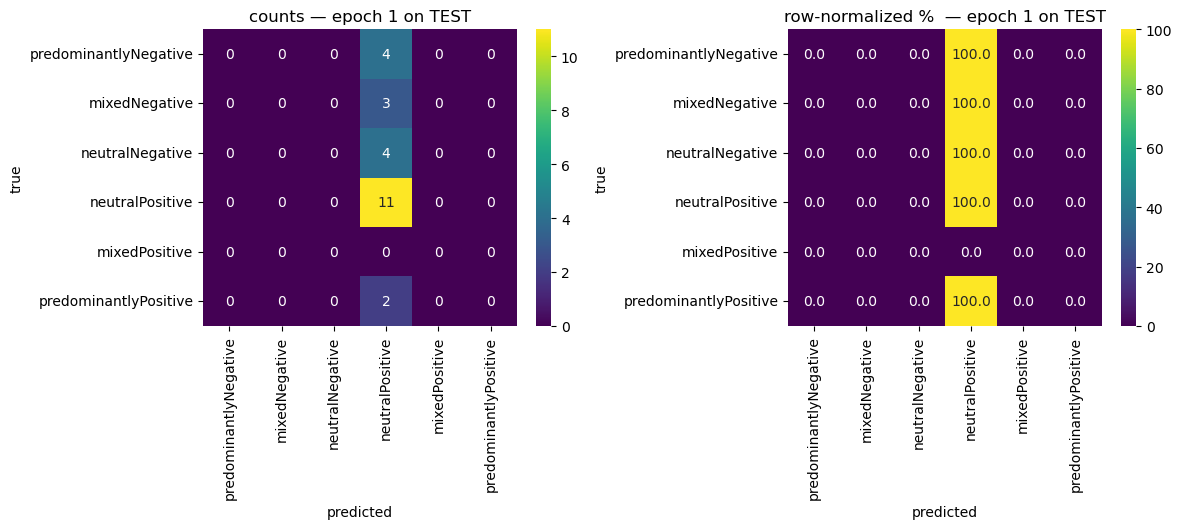

In [20]:
if cfg.task_type == "classification":
    best_epoch_dir = run_dir / "phase2_test" / "epoch_logs" / f"epoch_{phase2_best['epoch']}"
    preds_path = best_epoch_dir / "predictions.json"
    if not preds_path.exists():
        raise FileNotFoundError(f"Expected predictions at {preds_path}, but it's missing.")

    preds_data = json.loads(preds_path.read_text())
    y_true_idx = [int(p["gold_raw"]) for p in preds_data]
    y_pred_idx = [label2id[p["pred_label"]] for p in preds_data]

    str_labels = [str(x) for x in cfg.label_order]
    n = len(cfg.label_order)
    cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(n)))
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_rel = np.divide(cm.astype(float), row_sums,
                       out=np.zeros_like(cm, dtype=float),
                       where=row_sums != 0) * 100.0

    fig, axes = plt.subplots(1, 2, figsize=(max(12, n * 2.0), max(5, n * 0.9)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
                xticklabels=str_labels, yticklabels=str_labels, ax=axes[0])
    axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
    axes[0].set_title(f"counts — epoch {phase2_best['epoch']} on TEST")

    sns.heatmap(cm_rel, annot=True, fmt=".1f", cmap="viridis",
                xticklabels=str_labels, yticklabels=str_labels, ax=axes[1])
    axes[1].set_xlabel("predicted"); axes[1].set_ylabel("true")
    axes[1].set_title(f"row-normalized %  — epoch {phase2_best['epoch']} on TEST")

    plt.tight_layout()
    plt.show()
else:
    print(f"(skipped — task_type={cfg.task_type!r}, see per-epoch scatter/distribution PNGs)")


---

## 18. What's next

This run wrote per-epoch logs + a saved best model under `runs/`. Chapter 5 (`5_analysis/`) loads run directories like this one and produces error-analysis CSVs and cross-run comparisons.

For a second target on the same dataset, change two lines of Config (`label_key`, maybe `label_order`) and re-run. For ROG sentiment as regression, set `task_type="regression"` and provide `label_scale={ "predominantlyNegative": -2, ..., "predominantlyPositive": 3 }` (or whatever ramp makes sense).